# 🪟 Window Functions — SQL + Insight + Plot

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect()

INPUT_PATH = "/Users/max/mp/github/data-warehousing/syllabus/week01-Foundations-SQL-for-Analytics/group_by_examples"
file_path = f"{INPUT_PATH}/sales.csv"

con.execute("""
CREATE OR REPLACE TABLE sales AS
SELECT * FROM read_csv_auto(?);
""", [file_path])

## Revenue by Product — SQL

In [4]:
pd.set_option('display.float_format', '{:,.2f}'.format)

df = con.execute("""SELECT product_name, SUM(sales_amount) AS revenue FROM sales GROUP BY product_name ORDER BY revenue DESC""").df()
df.head(20)

,product_name,revenue
0,LAPTOP,"768,190,852.20"
1,COMPUTER,"370,827,248.88"
2,EBIKE,"357,445,477.50"
3,IPAD,"275,450,514.66"
4,TV,"131,401,981.92"
5,BIKE,"102,737,295.30"
6,TABLE,"42,886,650.42"
7,WATCH,"40,543,899.70"
8,RADIO,"10,160,616.12"


## Business Insight

In [ ]:
print("""- Identify top products
- Revenue concentration
- Portfolio strategy""")

## Plot

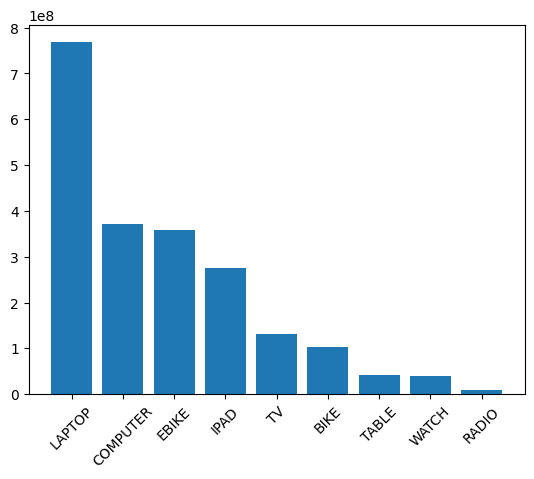

In [5]:
plt.figure(); plt.bar(df['product_name'], df['revenue']); plt.xticks(rotation=45); plt.show()

## Top 3 Products per Country — SQL

In [6]:
df = con.execute("""SELECT * FROM (SELECT country, product_name, SUM(sales_amount) AS revenue, RANK() OVER (PARTITION BY country ORDER BY SUM(sales_amount) DESC) rnk FROM sales GROUP BY country, product_name) t WHERE rnk <= 3""").df()
df.head()

,country,product_name,revenue,rnk
0,ITALY,LAPTOP,"28,013,112.00",1
1,ITALY,COMPUTER,"13,648,658.40",2
2,ITALY,EBIKE,"12,754,655.00",3
3,CHINA,LAPTOP,"105,545,634.00",1
4,CHINA,COMPUTER,"50,744,373.60",2


## Business Insight

In [7]:
print("""- Local preferences
- Market strategy
- Targeted campaigns""")

- Local preferences
- Market strategy
- Targeted campaigns


## Plot

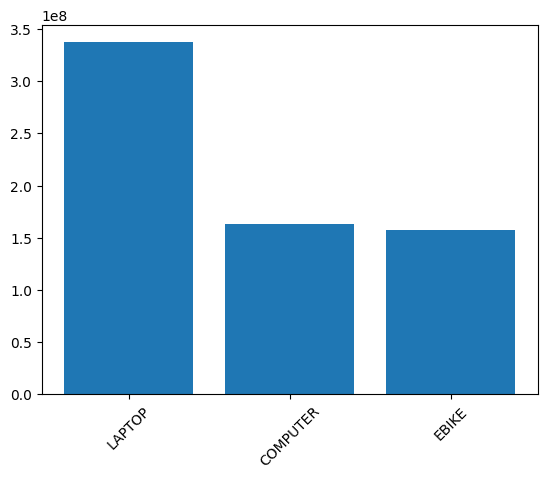

In [8]:
plt.figure(); plt.bar(df['product_name'], df['revenue']); plt.xticks(rotation=45); plt.show()

## Top Country per Year — SQL

In [9]:
df = con.execute("""SELECT * FROM (SELECT EXTRACT(YEAR FROM transaction_date) AS year, country, SUM(sales_amount) AS revenue, RANK() OVER (PARTITION BY EXTRACT(YEAR FROM transaction_date) ORDER BY SUM(sales_amount) DESC) rnk FROM sales GROUP BY year, country) t WHERE rnk = 1""").df()
df.head()

,year,country,revenue,rnk
0,2023,USA,"305,807,322.48",1
1,2025,USA,"307,125,902.16",1
2,2024,USA,"308,625,194.64",1


## Business Insight

In [10]:
print("""- Market leader tracking
- Geographic trends""")

- Market leader tracking
- Geographic trends


## Plot

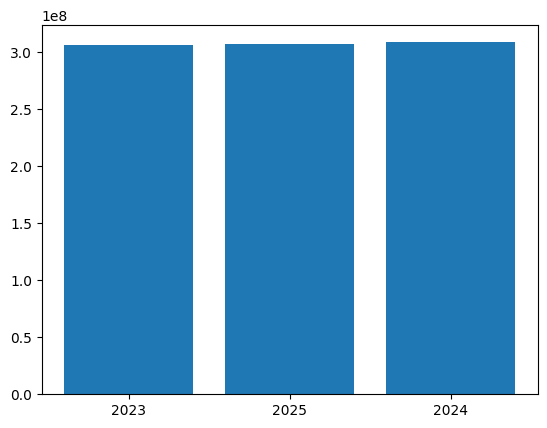

In [11]:
plt.figure(); plt.bar(df['year'].astype(str), df['revenue']); plt.show()

## Running Total — SQL

In [12]:
df = con.execute("""SELECT transaction_date, SUM(sales_amount) OVER (ORDER BY transaction_date) AS running_total FROM sales LIMIT 500""").df()
df.head()

,transaction_date,running_total
0,2023-01-01,"2,252,743.98"
1,2023-01-01,"2,252,743.98"
2,2023-01-01,"2,252,743.98"
3,2023-01-01,"2,252,743.98"
4,2023-01-01,"2,252,743.98"


## Business Insight

In [ ]:
print("""- Growth trajectory
- Business momentum""")

## Plot

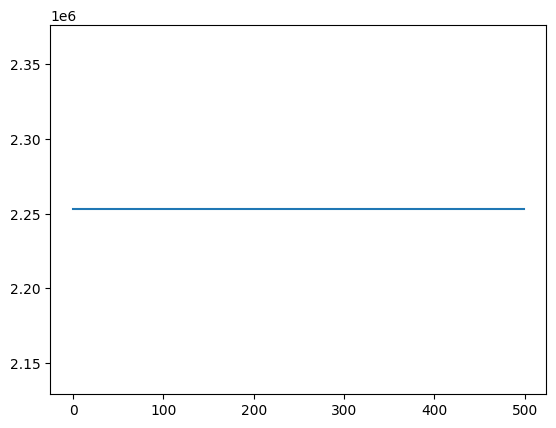

In [13]:
plt.figure(); plt.plot(df['running_total']); plt.show()